# 28. Калибровка вероятностей: когда «70%» действительно означает 70%

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`28_probability_calibration.py`](../28_probability_calibration.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 9 с |

**Цель.** Проверить и исправить вероятности классификатора, если по ним принимают денежные решения.

### Чему вы научитесь

- Диаграмма надёжности (reliability diagram)
- Ожидаемая ошибка калибровки (ECE), Брайер и log-loss
- Почему калибровка ломается: веса классов и переобучение
- Платт (сигмоида) и изотоническая регрессия на отдельной выборке через `CalibratedClassifierCV(FrozenEstimator(model))`

### Данные

`_data.make_customers` — 60 000 клиентов, отклик 5%.

### План

1. **Этап 1.** Данные: обучение 50%, калибровка 25%, тест 25%
2. **Этап 2.** Три модели: разумная, с весами классов и переобученная
3. **Этап 3.** Качество ранжирования и калибровки на тесте
4. **Этап 4.** Калибровка на отдельной выборке: Платт (sigmoid) и изотоническая
5. **Этап 5.** Диаграмма надёжности: средняя вероятность в корзине против доли откликов
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/28_probability_calibration.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_customers

ex = Example(EXAMPLES / "4_large/28_probability_calibration.py", title="28. Калибровка вероятностей",
             goal="проверить и исправить вероятности классификатора")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

## Этап 1. Данные: обучение 50%, калибровка 25%, тест 25%

In [2]:
X, y = make_customers(ex.size(60_000, 20_000), positive_rate=0.05, seed=28)
ex.describe(X, y, target="отклик", task="classification", source="examples/_data.py → make_customers")
X_tr, X_rest, y_tr, y_rest = train_test_split(X, y, test_size=0.5, stratify=y, random_state=0)
X_cal, X_te, y_cal, y_te = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=0)


def ece(y_true, p, bins=10):
    """Ожидаемая ошибка калибровки: средний |доля класса 1 − средняя вероятность| по корзинам равного размера."""
    order = np.argsort(p)
    return float(sum(len(b) / len(p) * abs(y_true[b].mean() - p[b].mean()) for b in np.array_split(order, bins)))

   Источник: examples/_data.py → make_customers
   Объектов: 60 000   признаков: 8   память: 2.86 МБ
   Типы признаков: float64 × 3, int64 × 3, category × 2
   Пропуски: доход 8.7%
   Цель «отклик»: класс 0 — 57034 (95.1%), класс 1 — 2966 (4.9%)
   Первые строки:


,возраст,доход,стаж_мес,покупок,дней_с_покупки,канал,регион,подписка,[отклик]
0,26.0,58000.0,31,0,49.0,партнёр,49,0,0
1,42.0,81685.0,39,3,15.0,приложение,2,0,0
2,37.0,44173.0,107,11,51.0,сайт,27,0,1


## Этап 2. Три модели: разумная, с весами классов и переобученная

In [3]:
models = {
    "разумная (300 деревьев, ν=0.05)": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                                                          min_child_samples=100, verbose=-1, random_state=0),
    "с весами классов (balanced)": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                                                      min_child_samples=100, class_weight="balanced", verbose=-1, random_state=0),
    "переобученная (2000 глубоких)": lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.1, num_leaves=127,
                                                        min_child_samples=5, verbose=-1, random_state=0),
}
for m in models.values():
    m.fit(X_tr, y_tr)

## Этап 3. Качество ранжирования и калибровки на тесте

In [4]:
print(f"   {'модель':32s} {'AUC':>6s} {'Брайер':>8s} {'log-loss':>9s} {'ECE':>7s} {'ср. p':>7s}")
print(f"   {'(доля откликов на тесте)':32s} {'':6s} {'':8s} {'':9s} {'':7s} {y_te.mean():7.4f}")
for name, m in models.items():
    p = m.predict_proba(X_te)[:, 1]
    print(f"   {name:32s} {roc_auc_score(y_te, p):6.4f} {brier_score_loss(y_te, p):8.5f} {log_loss(y_te, p):9.4f} "
          f"{ece(y_te, p):7.4f} {p.mean():7.4f}")
ex.note("""Веса классов раздувают вероятности (средняя 0.33 при доле откликов 0.05). Переобученная модель слишком уверена:
почти всем даёт вероятность около нуля, а на редких ошибках log-loss взлетает. Разумная модель откалибрована и без
исправлений — бустинг с log-loss и ранней остановкой обычно калиброван неплохо.""")

   модель                              AUC   Брайер  log-loss     ECE   ср. p
   (доля откликов на тесте)                                            0.0494
   разумная (300 деревьев, ν=0.05)  0.6970  0.04574    0.1868  0.0092  0.0486
   с весами классов (balanced)      0.6956  0.15897    0.4783  0.2809  0.3303


   переобученная (2000 глубоких)    0.6475  0.04931    0.6271  0.0467  0.0027


> ▸ **Вывод.** Веса классов раздувают вероятности (средняя 0.33 при доле откликов 0.05). Переобученная модель слишком уверена: почти всем даёт вероятность около нуля, а на редких ошибках log-loss взлетает. Разумная модель откалибрована и без исправлений — бустинг с log-loss и ранней остановкой обычно калиброван неплохо.

## Этап 4. Калибровка на отдельной выборке: Платт (sigmoid) и изотоническая

In [5]:
curves = {}
for name, m in models.items():
    row = []
    for method in ("sigmoid", "isotonic"):
        cal = CalibratedClassifierCV(FrozenEstimator(m), method=method).fit(X_cal, y_cal)
        p = cal.predict_proba(X_te)[:, 1]
        row.append((method, ece(y_te, p), log_loss(y_te, p), roc_auc_score(y_te, p)))
        if method == "isotonic":
            curves[name] = p
    print(f"   {name:32s} " + "   ".join(f"{mt}: ECE {e:.4f}, log-loss {ll:.4f}, AUC {a:.4f}" for mt, e, ll, a in row))
ex.note("""Калибровка монотонна и почти не меняет AUC (изотоническая даёт ступеньки, отсюда мелкие изменения),
но возвращает вероятностям смысл. Калибровочную выборку нельзя использовать при обучении модели.""")

   разумная (300 деревьев, ν=0.05)  sigmoid: ECE 0.0044, log-loss 0.1846, AUC 0.6970   isotonic: ECE 0.0047, log-loss 0.1866, AUC 0.6962
   с весами классов (balanced)      sigmoid: ECE 0.0059, log-loss 0.1849, AUC 0.6956   isotonic: ECE 0.0038, log-loss 0.1847, AUC 0.6919


   переобученная (2000 глубоких)    sigmoid: ECE 0.0041, log-loss 0.1895, AUC 0.6475   isotonic: ECE 0.0054, log-loss 0.1921, AUC 0.6431


> ▸ **Вывод.** Калибровка монотонна и почти не меняет AUC (изотоническая даёт ступеньки, отсюда мелкие изменения), но возвращает вероятностям смысл. Калибровочную выборку нельзя использовать при обучении модели.

## Этап 5. Диаграмма надёжности: средняя вероятность в корзине против доли откликов

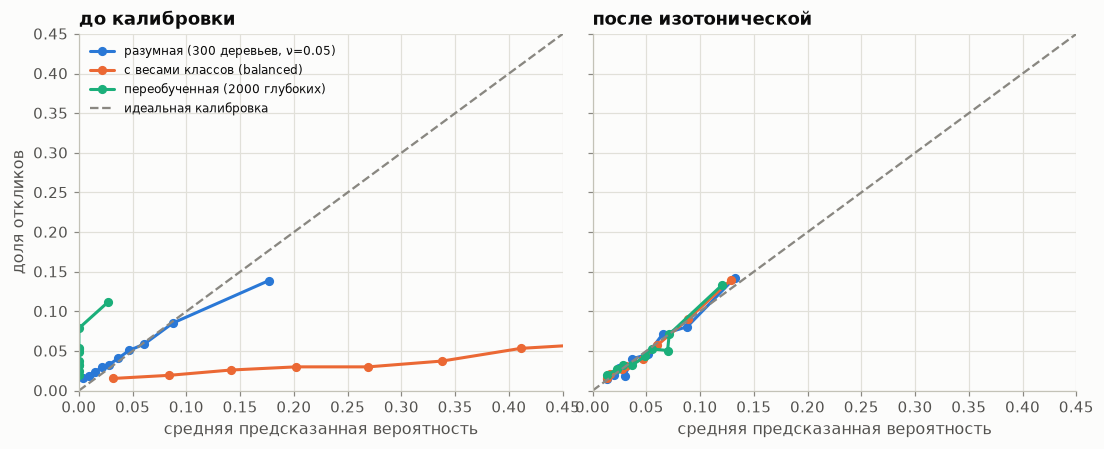

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
colors = [ROLE["model"], ROLE["tree"], ROLE["test"]]
for ax, title, source in ((axes[0], "до калибровки", None), (axes[1], "после изотонической", curves)):
    for (name, m), c in zip(models.items(), colors):
        p = m.predict_proba(X_te)[:, 1] if source is None else source[name]
        frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, "o-", color=c, lw=2, ms=5, label=name)
    lim = 0.45
    ax.plot([0, lim], [0, lim], color=ROLE["truth"], ls="--", lw=1.5, label="идеальная калибровка")
    ax.set(xlim=(0, lim), ylim=(0, lim), title=title, xlabel="средняя предсказанная вероятность")
axes[0].set_ylabel("доля откликов")
axes[0].legend(fontsize=8)
fig.tight_layout()
ex.finish(fig, "28_reliability")

## Этап 6. Выводы

In [7]:
ex.note("""Хорошая AUC не означает хороших вероятностей. Если вероятности идут в расчёт денег (ожидаемая выручка,
резервы, ставки) — проверяйте ECE и диаграмму надёжности и калибруйте на отдельной выборке.""")
ex.done()

> ▸ **Вывод.** Хорошая AUC не означает хороших вероятностей. Если вероятности идут в расчёт денег (ожидаемая выручка, резервы, ставки) — проверяйте ECE и диаграмму надёжности и калибруйте на отдельной выборке.

Готово за 7.1 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Сравните Платта и изотоническую калибровку при калибровочной выборке 1000 объектов.
2. Посчитайте ECE с 20 корзинами — как меняются числа?
3. Откалибруйте модель с ранней остановкой по log-loss — нужна ли ей калибровка?

## Что дальше

- **Теория в курсе:** [13.2 «Калибровка и интервалы»](../../../lessons/lesson_13_2/README.md).
- **Предыдущий пример:** [27. Ограничения из знаний о предметной области: монотонность и запрет взаимодействий](27_monotone_and_interaction_constraints.ipynb)
- **Следующий пример:** [29. От данных до сервиса: конвейер, проверка, сохранение, функция прогноза и карточка модели](29_end_to_end_pipeline.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)